In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv('bankChurn.csv')

In [3]:
df.head(20)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [5]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


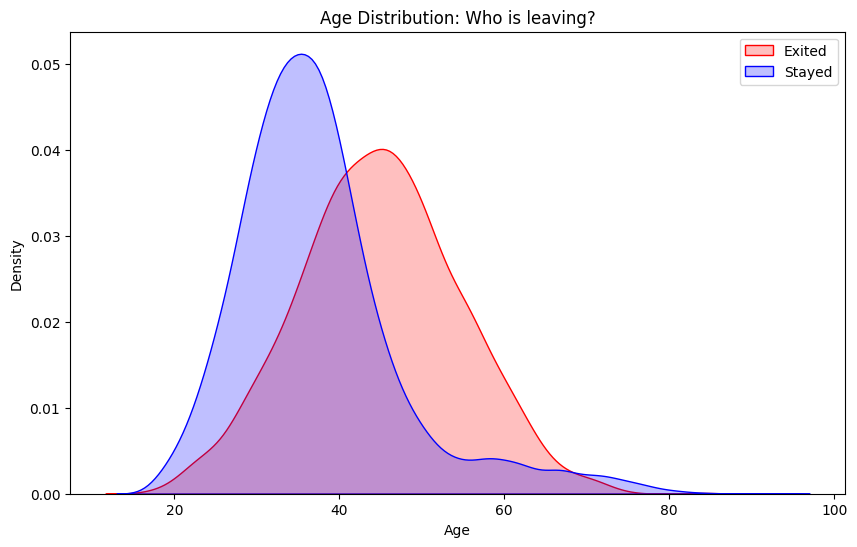

In [6]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['Exited'] == 1]['Age'], label='Exited', fill=True, color='red')
sns.kdeplot(df[df['Exited'] == 0]['Age'], label='Stayed', fill=True, color='blue')
plt.title('Age Distribution: Who is leaving?')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [7]:
fig = px.pie(df,names="Geography",title="Country")
fig.show()

In [8]:
fig = px.pie(df,names="Gender",title="Gender Distribution", color_discrete_map={'Male':'cyan', 'Female':'black'})
fig.show()

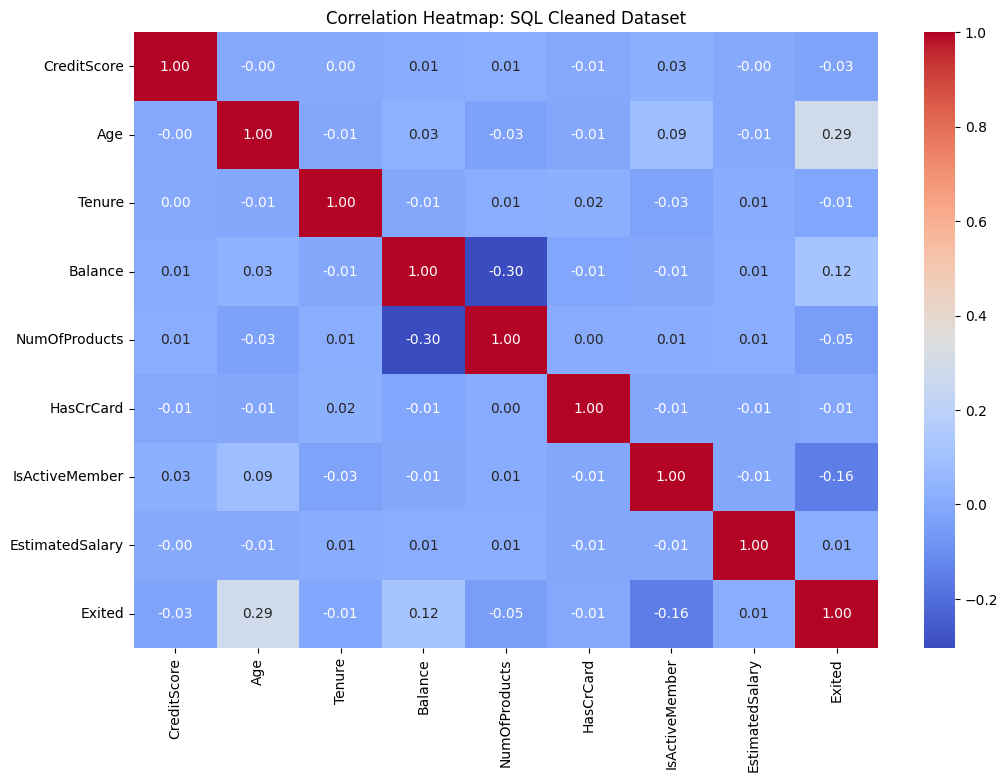

In [9]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap: SQL Cleaned Dataset')
plt.show()

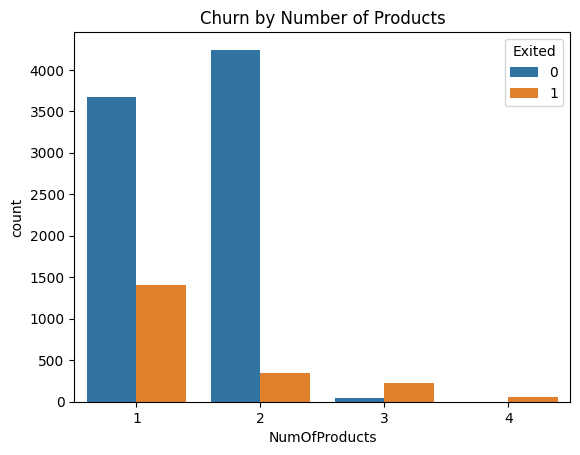

In [10]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title('Churn by Number of Products')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score

In [12]:
# Drop non-predictive columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, errors='ignore')

In [13]:
# This turns text columns into 1s and 0s
df_ml = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [14]:
df_ml.head(20)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
5,645,44,8,113755.78,2,1,0,149756.71,1,False,True,True
6,822,50,7,0.00,2,1,1,10062.80,0,False,False,True
7,376,29,4,115046.74,4,1,0,119346.88,1,True,False,False
8,501,44,4,142051.07,2,0,1,74940.50,0,False,False,True
9,684,27,2,134603.88,1,1,1,71725.73,0,False,False,True


In [15]:

# 1. Balance to Salary Ratio: Does the customer have high liquidity compared to their income?
df_ml['Balance_Salary_Ratio'] = df_ml['Balance'] / (df_ml['EstimatedSalary'] + 0.001) # Add 0.001 to prevent divide-by-zero

# 2. Tenure to Age Ratio: How much of their life have they spent with the bank?
df_ml['Tenure_Age_Ratio'] = df_ml['Tenure'] / df_ml['Age']

# 3. Credit Score to Age Ratio: Financial stability relative to age
df_ml['CreditScore_Age_Ratio'] = df_ml['CreditScore'] / df_ml['Age']

# 4. The "Product Paradox" Flag: Explicitly flag customers with 3 or more products based on our EDA
df_ml['Is_MultiProduct_Risk'] = df_ml['NumOfProducts'].apply(lambda x: 1 if x >= 3 else 0)

print("Feature Engineering Complete. New shape:", df_ml.shape)

Feature Engineering Complete. New shape: (10000, 16)


In [16]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

In [17]:
# this ddefine Features (X) and Target (y)
X = df_ml.drop('Exited', axis=1)
y = df_ml['Exited']

In [18]:
# Train/Test Split with Stratify (crucial for our 80/20 imbalance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
# Feature Scaling (Fit on train only to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [20]:
# --- HYPERPARAMETER TUNING & CROSS-VALIDATION ---
print("Starting Hyperparameter Tuning for Gradient Boosting...")

Starting Hyperparameter Tuning for Gradient Boosting...


In [21]:
# Define the grid of parameters to test
param_grid = {
    'n_estimators': [100, 200, 300],          # Number of trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Step size
    'max_depth': [3, 4, 5, 6],                # How deep each tree can grow
    'subsample': [0.8, 0.9, 1.0]              # Fraction of samples used per tree (prevents overfitting)
}

# 5-Fold Stratified Cross-Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize base model and Random Search
gb_base = GradientBoostingClassifier(random_state=42)
gb_tuned = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_grid,
    n_iter=15,               # Tests 15 random combinations
    scoring='roc_auc',       # Optimizing for ROC-AUC
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1                # Uses all processor cores to speed up
)

In [22]:
gb_tuned.fit(X_train_scaled, y_train)
best_model = gb_tuned.best_estimator_

print("Tuning Complete!")
print("Best Parameters:", gb_tuned.best_params_)
print("Best Cross-Validation ROC-AUC:", round(gb_tuned.best_score_, 4))

Tuning Complete!
Best Parameters: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
Best Cross-Validation ROC-AUC: 0.8602


In [23]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [24]:
# --- ADVANCED EVALUATION ---
predictions = best_model.predict(X_test_scaled)
probs = best_model.predict_proba(X_test_scaled)[:, 1]

In [25]:
# 1. Classification Report (Shows Precision, Recall, F1 for BOTH classes)
print("--- Classification Report ---")
print(classification_report(y_test, predictions))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}\n")

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.79      0.50      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.77      2000
weighted avg       0.86      0.87      0.86      2000

Final Test ROC-AUC Score: 0.8663



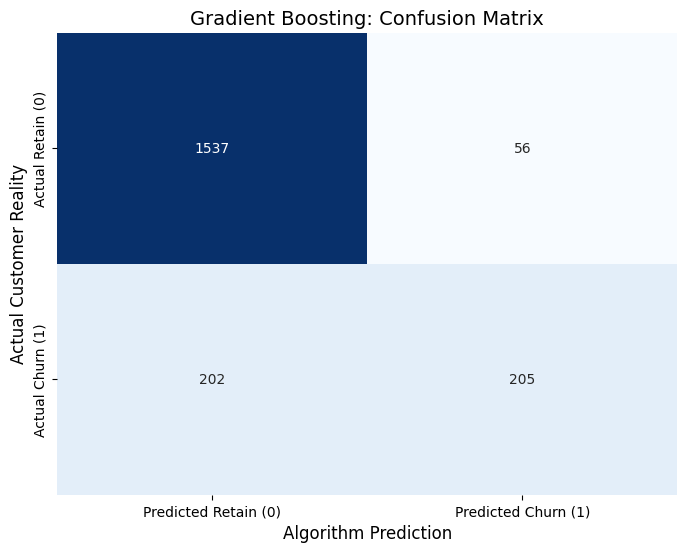

In [26]:
# 2. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Retain (0)', 'Predicted Churn (1)'],
            yticklabels=['Actual Retain (0)', 'Actual Churn (1)'])
plt.title('Gradient Boosting: Confusion Matrix', fontsize=14)
plt.xlabel('Algorithm Prediction', fontsize=12)
plt.ylabel('Actual Customer Reality', fontsize=12)
plt.show()

In [31]:
!pip install shap

In [32]:
# --- SHAP INTERPRETATION ANALYSIS ---
print("Generating SHAP values to explain model logic...")

Generating SHAP values to explain model logic...


In [35]:
import shap

# Initialize the Tree Explainer for our tuned Gradient Boosting model
explainer = shap.TreeExplainer(best_model)

In [36]:
# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

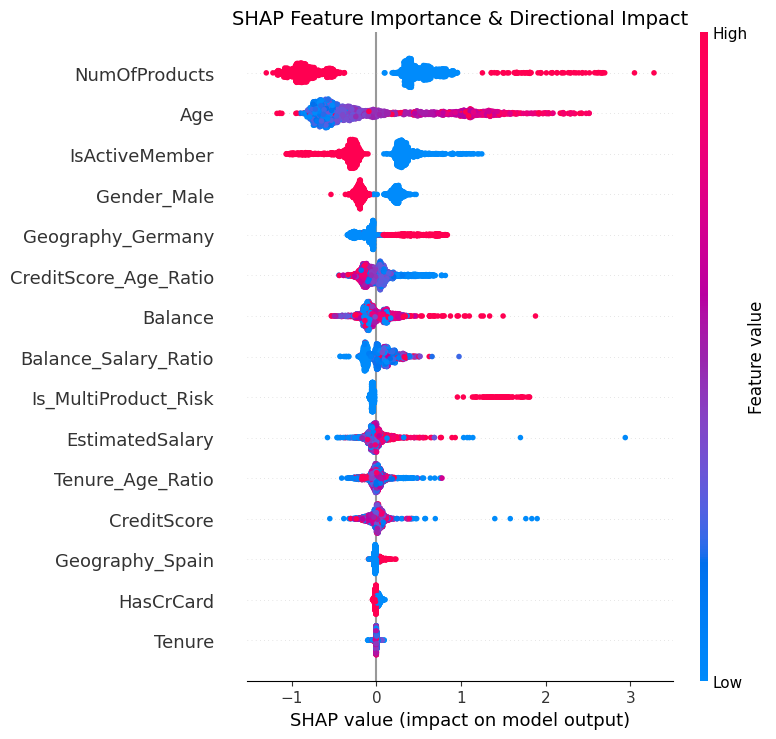

In [37]:
# Plot the SHAP Summary Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Feature Importance & Directional Impact", fontsize=14)
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot")

In [38]:
# --- FINAL DEPLOYMENT: PREDICTING FOR THE ENTIRE DATASET ---
print("Generating final predictions for the Tableau Dashboard...")


Generating final predictions for the Tableau Dashboard...


In [39]:
# 1. Scale the ENTIRE dataset (using the scaler we strictly fitted on the training data earlier)
X_all_scaled = pd.DataFrame(scaler.transform(X), columns=X.columns)


In [40]:
# 2. Predict probabilities for every single customer using our newly tuned model
full_probs = best_model.predict_proba(X_all_scaled)[:, 1]


In [41]:
# 3. Load the original raw data so the business has readable columns (like Surname, Geography)
df_final = pd.read_csv('Churn_Modelling.csv')


In [42]:
# 4. Append our predictive intelligence
df_final['Churn_Probability'] = full_probs


In [43]:
# 5. Apply the business logic threshold to create actionable Risk Segments
df_final['Risk_Segment'] = df_final['Churn_Probability'].apply(
    lambda x: 'Critical' if x > 0.7 else ('Medium' if x > 0.4 else 'Low')
)

In [44]:

# 6. Export the final dataset
df_final.to_csv('Final_Churn_Predictions.csv', index=False)
print("\nSuccess! 'Final_Churn_Predictions.csv' has been generated and is ready for Tableau.")


Success! 'Final_Churn_Predictions.csv' has been generated and is ready for Tableau.
